In [17]:
import torch
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [18]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # add this
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder("../data/cats_vs_dogs/train", transform=train_transform)
val_dataset   = datasets.ImageFolder("../data/cats_vs_dogs/val",   transform=val_transform)

from torch.utils.data import DataLoader, Subset
import random

random.seed(42)
train_subset = Subset(train_dataset, random.sample(range(len(train_dataset)), 2000))
val_subset   = Subset(val_dataset,   random.sample(range(len(val_dataset)),   500))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=32, shuffle=False)

print(f"Train subset: {len(train_subset)}")
print(f"Val subset:   {len(val_subset)}")

print(f"Classes: {train_dataset.classes}")
print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")


Train subset: 2000
Val subset:   500
Classes: ['cat', 'dog']
Train size: 19998
Val size:   5000


In [19]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [20]:
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(512, 2)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable:,}")
print(f"Total params:     {total:,}")
print(f"Frozen params:    {total - trainable:,}")


Trainable params: 1,026
Total params:     11,177,538
Frozen params:    11,176,512


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 5 

for epoch in range(epochs):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) 
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_subset)
    train_loss = total_loss / len(train_loader)

    model.eval()
    val_loss_total, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)
            val_loss_total += loss.item()
            val_correct += (output.argmax(1) == labels).sum().item()
        
        val_acc  = val_correct / len(val_subset)
        val_loss = val_loss_total / len(val_loader)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Using device: cpu
Epoch 1/5 | Train Loss: 0.2807 | Train Acc: 0.8935 | Val Acc: 0.9700
Epoch 2/5 | Train Loss: 0.1418 | Train Acc: 0.9445 | Val Acc: 0.9720
Epoch 3/5 | Train Loss: 0.1092 | Train Acc: 0.9580 | Val Acc: 0.9660
Epoch 4/5 | Train Loss: 0.1184 | Train Acc: 0.9545 | Val Acc: 0.9600
Epoch 5/5 | Train Loss: 0.1128 | Train Acc: 0.9570 | Val Acc: 0.9620


# Visualize CNN feature maps

In [22]:
print(model.conv1)

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


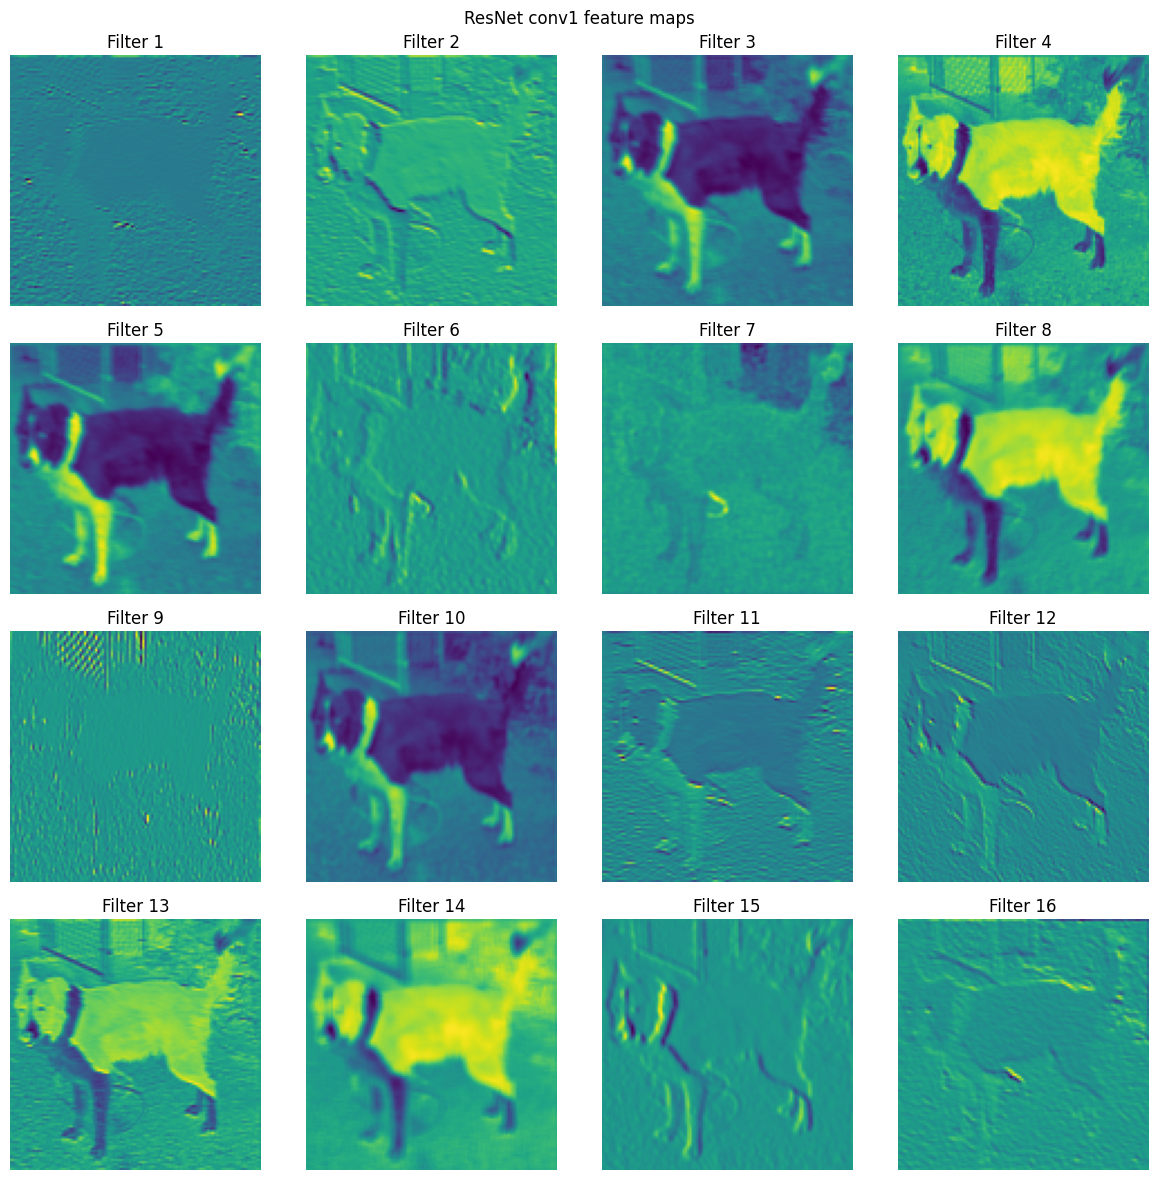

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# get one image from val loader
images, labels = next(iter(val_loader))
img = images[0].unsqueeze(0)  # shape: (1, 3, 224, 224)

# hook to capture feature maps
feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output)

# register hook on first conv layer
hook = model.conv1.register_forward_hook(hook_fn)

# forward pass
model.eval()
with torch.no_grad():
    model(img)

hook.remove()

# visualize first 16 feature maps
fmap = feature_maps[0].squeeze(0)  # shape: (64, 112, 112)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmap[i].cpu().numpy(), cmap='viridis')
    ax.axis('off')
    ax.set_title(f'Filter {i+1}')

plt.suptitle('ResNet conv1 feature maps')
plt.tight_layout()
plt.show()

# Grad-CAM

In [35]:
images, labels = next(iter(val_loader))
img = images[0].unsqueeze(0)  
print(img.shape)
# print(model)

torch.Size([1, 3, 224, 224])


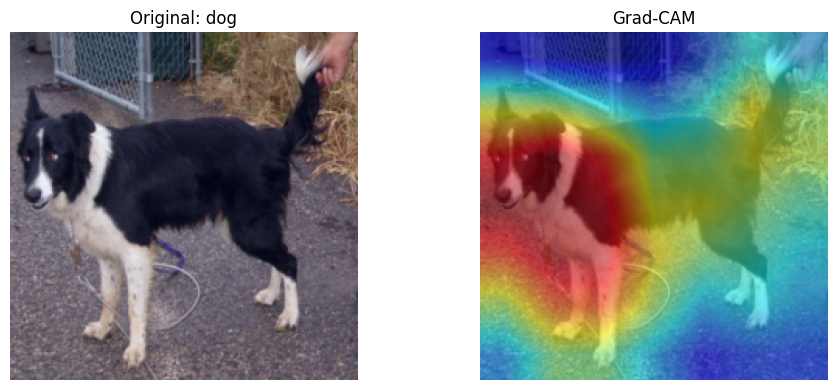

In [39]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import numpy as np

for param in model.layer4.parameters():
    param.requires_grad=True

# get one image
images, labels = next(iter(val_loader))
img_tensor = images[0].unsqueeze(0)  # (1, 3, 224, 224)

# target layer — last conv layer in ResNet
target_layer = [model.layer4[-1]]

# run Grad-CAM
cam = GradCAM(model=model, target_layers=target_layer)
targets = [ClassifierOutputTarget(labels[0].item())]
grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

# prepare original image for visualization
orig = images[0].permute(1, 2, 0).numpy()
orig = (orig - orig.min()) / (orig.max() - orig.min())

# overlay CAM on image
visualization = show_cam_on_image(orig.astype(np.float32), grayscale_cam, use_rgb=True)

# plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig)
axes[0].set_title(f"Original: {'cat' if labels[0]==0 else 'dog'}")
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM")
axes[1].axis('off')

plt.tight_layout()
plt.show()